# Feature-ceiling diagnostics

Two checks for *why* every model tops out near PR-AUC ~0.19 on this dataset:

1. **Multi-model-family comparison** — if structurally different models (linear, neural net, boosted trees) all plateau at the same recall / PR-AUC, the bottleneck is the **information in the features**, not model capacity.
2. **Class-overlap diagnostics** — look at `P(feature | fraud)` vs `P(feature | not fraud)` and a k-NN Bayes-error estimate. Heavy overlap caps the achievable recall for *any* model.

All data comes from the shared `src` pipeline, so the features here are identical to what the models in `02_models.ipynb` see.

## Setup

In [2]:
!pip install imblearn

Defaulting to user installation because normal site-packages is not writeable

   ---------------------------------------- 0/3 [sklearn-compat]
   ---------------------------------------- 0/3 [sklearn-compat]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbal


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: C:\Users\ASUS\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make `src` importable from the notebooks/ dir.
repo_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

# from src.data.load_data import load_data
from src.data.clean_data import clean_data
from src.data.preprocess import preprocess
from src.features.features_engineer import features_engineer
from src.features.undersampling import undersampling
from src.data.data_split import data_split
from src.services.metrics import evaluate_model

In [4]:
# Run the shared pipeline. Output is already all-numeric, standardized, one-hot, no NaN,
# so every model family below can consume it directly.
# df = load_data()
df = pd.read_csv("../data/Base.csv")
X_train, X_test, y_train, y_test = data_split(features_engineer(preprocess(clean_data(df))))
X_train, y_train = undersampling(X_train, y_train)
print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("fraud rate  train: {:.2%}  test: {:.2%}".format(y_train.mean(), y_test.mean()))

X_train: (16302, 50) | X_test: (205011, 50)
fraud rate  train: 50.00%  test: 1.40%


In [5]:
from sklearn.metrics import f1_score

# Shared protocol: fit each model, pick the F1-optimal threshold on its training
# scores, and evaluate on the full, untouched test set.


def positive_scores(model, X):
    """Positive-class probability for both sklearn (2-D) and src (1-D) models."""
    p = np.asarray(model.predict_proba(X))
    return p[:, 1] if p.ndim == 2 else p


def best_f1_threshold(y_true, y_score):
    ts = np.linspace(0.01, 0.99, 99)
    f1s = [f1_score(y_true, (y_score >= t).astype(int), zero_division=0) for t in ts]
    return ts[int(np.argmax(f1s))]

# Diagnosis 1 — Multi-model-family comparison

Four structurally different hypothesis classes, each at its **tuned config from `config.json`**, trained on the **full training set** (the boosters early-stop on a small held-out slice) and evaluated on the untouched test set (months 6–7).

- **Logistic regression (L2)** — linear boundary
- **MLP** — small neural net
- **XGBoost / LightGBM / CatBoost** — boosted trees, tuned params + early stopping

We report PR-AUC **and recall @ 5% FPR** (the operational fraud metric). If every family lands at nearly the same ceiling, capacity is not the bottleneck.

In [17]:
import json
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import precision_recall_curve
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import lightgbm as lgb

cfg = json.load(open("../config.json"))
spw = (y_train == 0).sum() / (y_train == 1).sum()  # imbalance ratio for the boosters

# Train on the full training set. The boosters early-stop on a small held-out slice;
# the test set (months 6-7) is never touched.
X_fit, X_val, y_fit, y_val = X_train, X_test, y_train, y_test

results, pr_curves = {}, {}


def record(name, model):
    train_score = positive_scores(model, X_fit)
    test_score = positive_scores(model, X_test)
    t = best_f1_threshold(y_fit, train_score)
    # evaluate_model already returns recall@5fpr, so no need to recompute it here.
    m = evaluate_model(y_test, (test_score >= t).astype(int), test_score)
    m["threshold"] = t
    results[name] = m
    precision, recall, _ = precision_recall_curve(y_test, test_score)
    pr_curves[name] = (recall, precision)
    print(f"{name:10s} done  (pr_auc={m['pr_auc']:.3f}, recall@5fpr={m['recall@5fpr']:.3f})")


# --- linear ---
lr_params = dict(cfg.get("LogReg_best_params", {}))
if lr_params.get("class_weight") == "None":  # config stored the string "None"
    lr_params["class_weight"] = None
logreg = LogisticRegression(**lr_params, max_iter=1000)
logreg.fit(X_fit, y_fit)
record("logreg_l2", logreg)

# --- neural ---
mlp = MLPClassifier(hidden_layer_sizes=(64, 32), early_stopping=True, random_state=42)
mlp.fit(X_fit, y_fit)
record("mlp", mlp)

# --- boosters: tuned params + early stopping on X_val ---
xgb_model = XGBClassifier(
    **cfg["XGBoost_best_params"],
    # n_estimators=2000,
    # scale_pos_weight=spw,
    # tree_method="hist",
    # eval_metric="aucpr",
    # early_stopping_rounds=50,
    # n_jobs=-1,
    # random_state=42,
)
xgb_model.fit(X_fit, y_fit)
record("xgboost", xgb_model)

lgbm = LGBMClassifier(
    **cfg["LightGBM_best_params"],
    # n_estimators=2000,
    # subsample_freq=1,
    # scale_pos_weight=spw,
    # n_jobs=-1,
    # random_state=42,
    # verbose=-1,
)
lgbm.fit(
    X_fit,
    y_fit,
)
record("lightgbm", lgbm)

cat = CatBoostClassifier(
    **cfg["CatBoost_best_params"],
    # iterations=2000,
    # scale_pos_weight=spw,
    # random_seed=42,
    # verbose=0,
)
cat.fit(X_fit, y_fit)
record("catboost", cat)

results_df = pd.DataFrame(results).T.sort_values("pr_auc", ascending=False)
results_df[["pr_auc", "recall@5fpr", "recall", "precision", "f1_score", "threshold"]]

logreg_l2  done  (pr_auc=0.153, recall@5fpr=0.491)
mlp        done  (pr_auc=0.166, recall@5fpr=0.510)
xgboost    done  (pr_auc=0.194, recall@5fpr=0.549)
lightgbm   done  (pr_auc=0.192, recall@5fpr=0.543)
catboost   done  (pr_auc=0.196, recall@5fpr=0.552)


,pr_auc,recall@5fpr,recall,precision,f1_score,threshold
catboost,0.195509,0.551772,0.849201,0.050471,0.095279,0.46
xgboost,0.193537,0.549340,0.873176,0.046323,0.087979,0.42
lightgbm,0.191574,0.543085,0.873523,0.045178,0.085913,0.41
mlp,0.166385,0.510076,0.866227,0.044189,0.084088,0.41
logreg_l2,0.153243,0.490966,0.847116,0.046485,0.088134,0.40


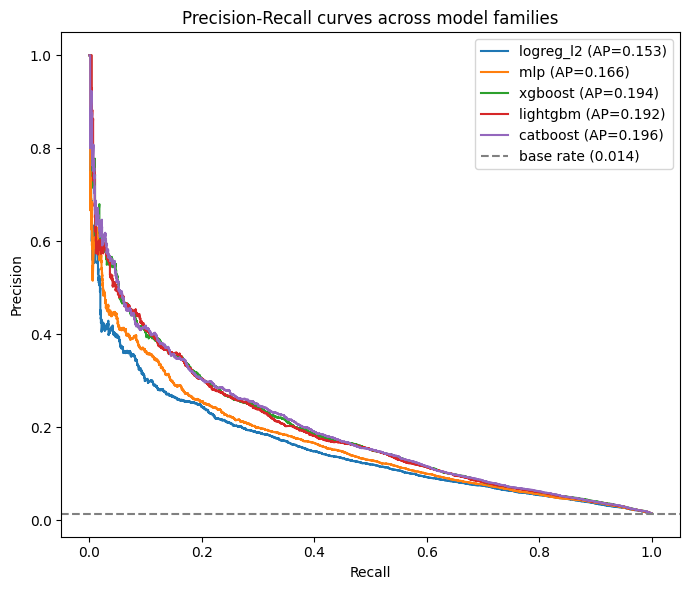

In [18]:
# PR curves overlaid — clustered curves = a shared ceiling.
plt.figure(figsize=(7, 6))
for name, (rec, prec) in pr_curves.items():
    plt.plot(rec, prec, label=f"{name} (AP={results[name]['pr_auc']:.3f})")
plt.axhline(y_test.mean(), ls="--", color="gray", label=f"base rate ({y_test.mean():.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall curves across model families")
plt.legend()
plt.tight_layout()
plt.show()

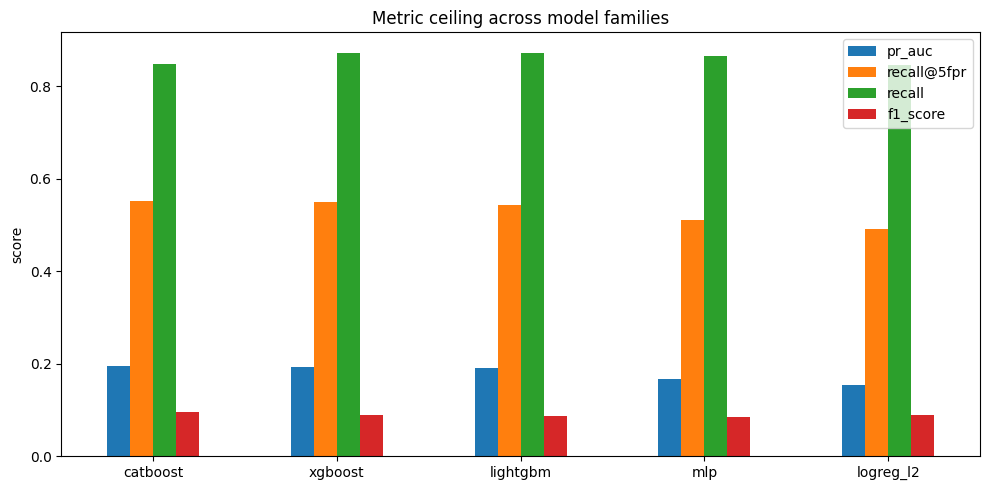

In [19]:
# Both metrics side by side across families — level bars = a shared ceiling.
ax = results_df[["pr_auc", "recall@5fpr", "recall", "f1_score"]].plot.bar(figsize=(10, 5))
ax.set_title("Metric ceiling across model families")
ax.set_ylabel("score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Read it like this:** if the PR curves cluster and both PR-AUC and recall@5%FPR are level across a linear model, a neural net, and three *tuned* boosters, then no architecture extracts signal the others miss — the ceiling is set by the features, not the model.

# Diagnosis 2 — Class overlap

If the models are feature-limited, we should *see* it: the most-informative features should have nearly identical distributions for fraud vs non-fraud, and fraud points should sit inside non-fraud neighborhoods.

In [ ]:
from sklearn.feature_selection import mutual_info_classif

# Rank features by mutual information with the target (swap in your IV ranking if you prefer).
samp = X_train.sample(30_000, random_state=42)
mi = mutual_info_classif(samp, y_train.loc[samp.index], random_state=42)
mi_scores = pd.Series(mi, index=X_train.columns).sort_values(ascending=False)
top_features = mi_scores.head(6).index.tolist()
mi_scores.head(10)

is_bank_months_count_available            0.007828
is_device_distinct_emails_8w_available    0.006337
source_INTERNET                           0.005569
employment_status_CA                      0.005257
phone_mobile_valid                        0.004789
housing_status_BA                         0.004646
keep_alive_session                        0.004458
proposed_credit_limit                     0.004377
email_is_free                             0.004040
housing_status_BC                         0.003492
dtype: float64

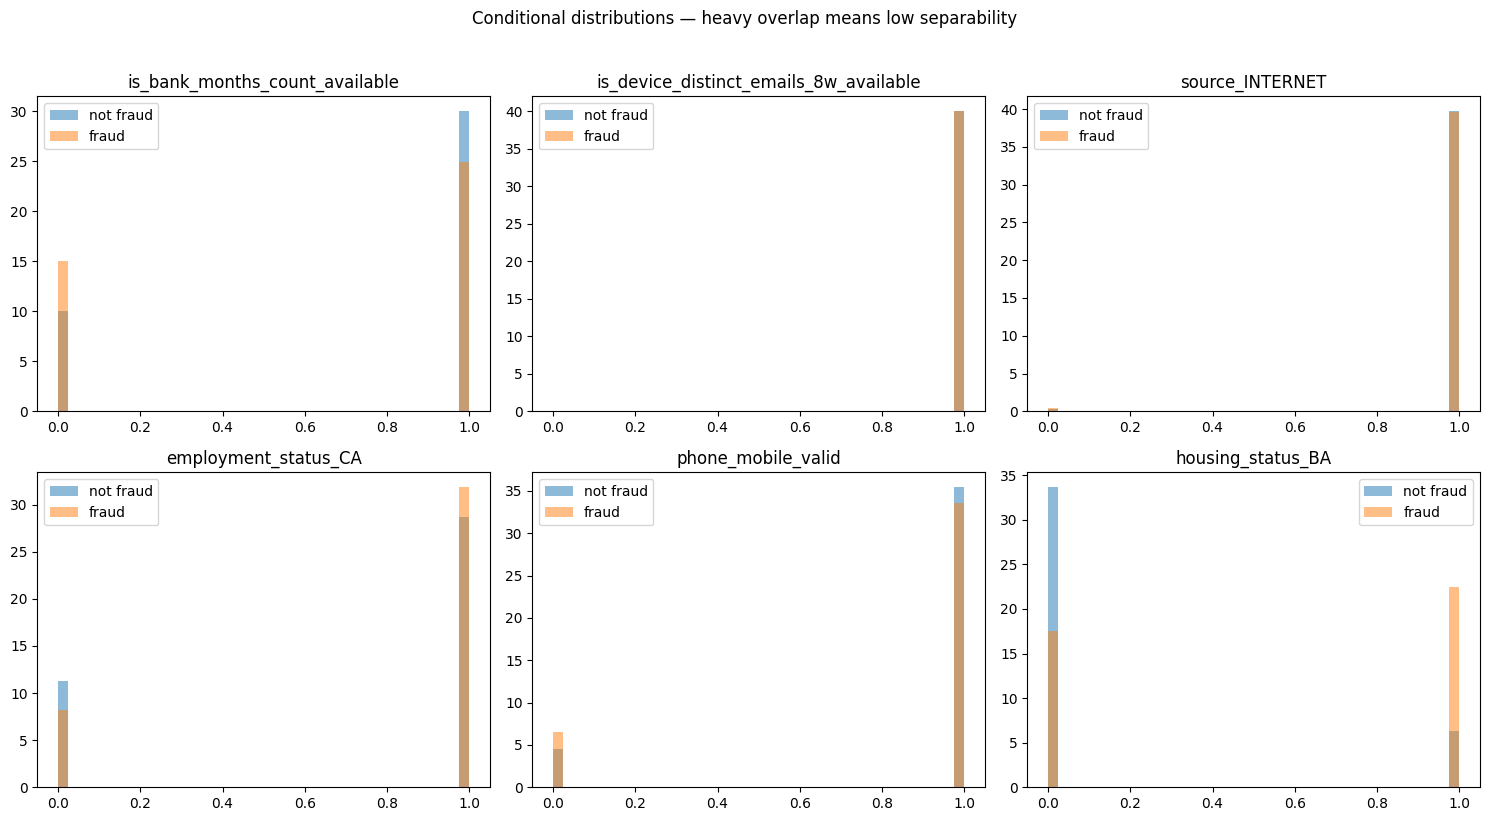

In [ ]:
# Conditional distributions: P(feature | fraud) vs P(feature | not fraud).
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feat in zip(axes.ravel(), top_features):
    legit = X_train.loc[y_train == 0, feat]
    fraud = X_train.loc[y_train == 1, feat]
    bins = np.histogram_bin_edges(X_train[feat], bins=40)
    ax.hist(legit, bins=bins, density=True, alpha=0.5, label="not fraud")
    ax.hist(fraud, bins=bins, density=True, alpha=0.5, label="fraud")
    ax.set_title(feat)
    ax.legend()
fig.suptitle("Conditional distributions — heavy overlap means low separability", y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.neighbors import NearestNeighbors

# k-NN Bayes-error estimate: are fraud points surrounded by non-fraud points?
K = 15
idx = X_train.sample(20_000, random_state=42).index
Xs, ys = X_train.loc[idx].to_numpy(), y_train.loc[idx].to_numpy()

nn = NearestNeighbors(n_neighbors=K + 1).fit(Xs)  # +1 because the closest point is itself
_, neigh = nn.kneighbors(Xs)
local_fraud_rate = ys[neigh[:, 1:]].mean(axis=1)  # fraud fraction among the K neighbors

print(f"overall fraud rate in sample:            {ys.mean():.2%}")
print(f"neighbor fraud-rate around FRAUD points: {local_fraud_rate[ys == 1].mean():.2%}")
print(f"neighbor fraud-rate around LEGIT points: {local_fraud_rate[ys == 0].mean():.2%}")

one_nn_err = (ys[neigh[:, 1]] != ys).mean()  # leave-one-out 1-NN error
print(f"\n1-NN leave-one-out error: {one_nn_err:.2%}  (Bayes error is roughly half of this)")

overall fraud rate in sample:            1.00%
neighbor fraud-rate around FRAUD points: 5.23%
neighbor fraud-rate around LEGIT points: 0.91%

1-NN leave-one-out error: 1.84%  (Bayes error is roughly half of this)


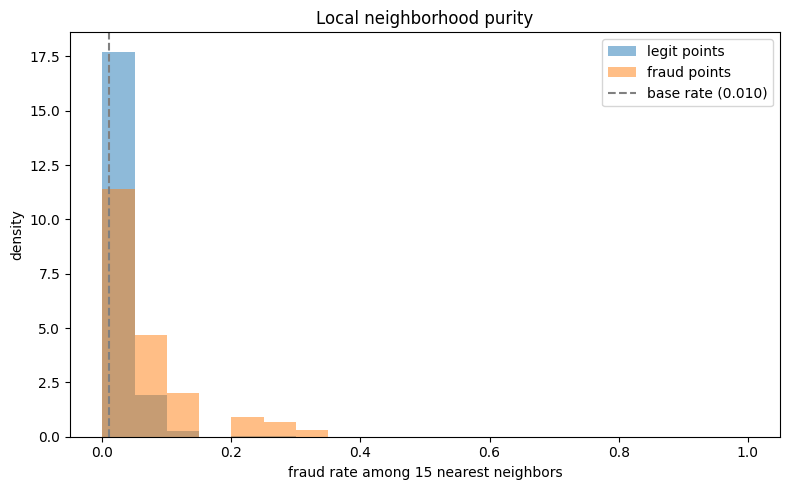

In [ ]:
# Where do fraud points live? If their neighborhoods are no more fraud-dense than the base
# rate, they sit in overlap regions and recall is capped for any model.
plt.figure(figsize=(8, 5))
edges = np.linspace(0, 1, 21)
plt.hist(local_fraud_rate[ys == 0], bins=edges, density=True, alpha=0.5, label="legit points")
plt.hist(local_fraud_rate[ys == 1], bins=edges, density=True, alpha=0.5, label="fraud points")
plt.axvline(ys.mean(), ls="--", color="gray", label=f"base rate ({ys.mean():.3f})")
plt.xlabel(f"fraud rate among {K} nearest neighbors")
plt.ylabel("density")
plt.title("Local neighborhood purity")
plt.legend()
plt.tight_layout()
plt.show()

**Read it like this:** if the fraud-point histogram piles up near the base rate (left side) instead of near 1.0, most frauds are locally indistinguishable from legitimate applications. Combined with Diagnosis 1, that is strong, model-independent evidence the features simply do not carry enough signal to push recall higher.